# Importing libs and data

In [2]:
# loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import numpy as np
from statsmodels.tsa.seasonal import STL, seasonal_decompose
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch
from scipy import stats
from scipy.stats import gaussian_kde
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import het_arch
from pathlib import Path
import os


In [3]:
# loading the cleaned DataFrame
base_path = Path(os.getcwd())

input_path  = base_path / r"..\..\Data\Cleaned\df_bologna_cleaned.parquet"

df = pd.read_parquet(input_path)

# Agregating into daily Statistics

In [4]:
df_daily_2 = (
    df.groupby(df['time'].dt.date)
    .agg(
        GHI_sum       = ('GHI',           'sum'),
        GHI_cs_sum    = ('CLEAR_SKY_GHI', 'sum'),
        GHI_var       = ('GHI',           'var'),
    )
    .assign(
        Kt_daily   = lambda x: x['GHI_sum'] / x['GHI_cs_sum']
    )
    .rename_axis('date')
    .reset_index()
)

# Reorder columns
df_daily_2 = df_daily_2[['date', 'GHI_sum', 'GHI_cs_sum', 'Kt_daily', 'GHI_var']]

#create the year column
df_daily_2['year'] = pd.to_datetime(df_daily_2['date']).dt.year

#create the month column
df_daily_2['month'] = pd.to_datetime(df_daily_2['date']).dt.month

#set the date columns as datetime and index
df_daily_2['date'] = pd.to_datetime(df_daily_2['date'])



# Transformation

In [5]:
EPS = 1e-3

def transform_kt_to_Yt(
    kt: pd.Series,
) -> tuple[pd.Series, dict]:
    """
    Map Kt_daily ∈ (0,1) to an unbounded Y_t ∈ ℝ using the logit link.

    Returns
    -------
    Yt     : pd.Series — unbounded transformed series
    params : dict      — α, β (required for inversion)
    """
    Xt = 1.0 - kt

    alpha = float(Xt.min()) - EPS
    beta  = float(Xt.max() - Xt.min()) + 2 * EPS

    Xp = (Xt - alpha) / beta                          # X'_t ∈ (0, 1) strictly
    Yt = pd.Series(
        np.log(Xp.values / (1.0 - Xp.values)),        # logit
        index=kt.index,
        name="Y_t"
    )

    return Yt, {"alpha": alpha, "beta": beta}


def invert_Yt_to_GHI(
    Yt: pd.Series,
    Ct: pd.Series,
    params: dict
) -> pd.Series:
    """
    Recover R_t = C_t * (1 - α - β * σ(Y_t)), where σ is the logistic function.
    Guarantees R_t ∈ [0, C_t] without truncation.
    """
    alpha, beta = params["alpha"], params["beta"]
    Xp_rec = 1.0 / (1.0 + np.exp(-Yt.values))        # logistic (logit inverse)
    Xt_rec = alpha + beta * Xp_rec
    return pd.Series(
        Ct.values * (1.0 - Xt_rec),
        index=Yt.index,
        name="GHI_reconstructed"
    )

In [6]:
kt  = df_daily_2.set_index("date")["Kt_daily"].dropna()
Ct  = df_daily_2.set_index("date")["GHI_cs_sum"].loc[kt.index]

Yt, params = transform_kt_to_Yt(kt)

# Inversion check — RMSE should be ≈ 0
GHI_rec = invert_Yt_to_GHI(Yt, Ct, params)
GHI_obs = df_daily_2.set_index("date")["GHI_sum"].loc[kt.index]
rmse    = np.sqrt(((GHI_obs - GHI_rec) ** 2).mean())

print(f"α = {params['alpha']:.6f},  β = {params['beta']:.6f}")
print(f"Y_t range : [{Yt.min():.3f}, {Yt.max():.3f}]")
print(f"Inversion RMSE : {rmse:.2e} kWh/m²  (expected ≈ 0)")

α = -0.001000,  β = 0.911341
Y_t range : [-6.814, 6.814]
Inversion RMSE : 1.91e-13 kWh/m²  (expected ≈ 0)


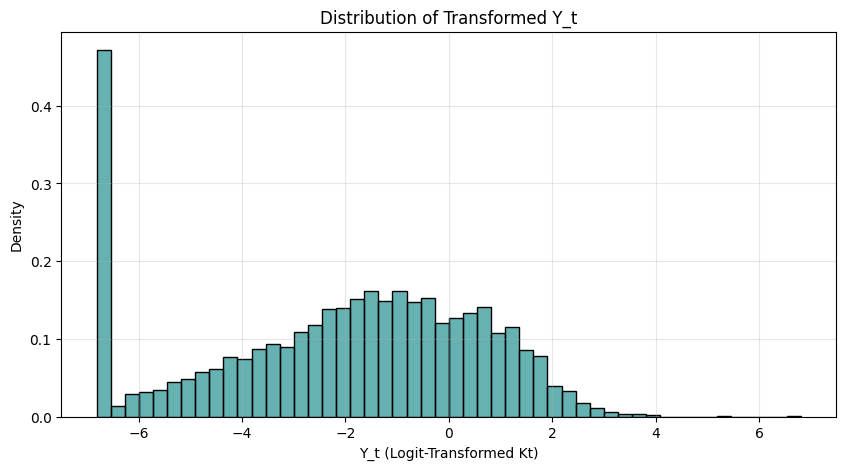

In [7]:
# check the distribution of Yt
plt.figure(figsize=(10, 5))
sns.histplot(Yt, bins=50, color='teal', alpha=0.6, stat='density')
plt.title("Distribution of Transformed Y_t", fontsize=12)
plt.xlabel("Y_t (Logit-Transformed Kt)")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()


# Decomposing

## Remove deterministic seasonal mean

In [8]:

# Y_t still carries a predictable intra-annual cycle inherited from the
# astronomical seasonality of GHI. A trigonometric function absorbs this

# Ȳ_t = a0 + a1·cos(2πt/365) + a2·sin(2πt/365)
# Ỹ_t = Y_t − Ȳ_t

from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

def remove_seasonal_mean(
    Yt: pd.Series,
) -> tuple[pd.Series, pd.Series, np.ndarray]:
    """
    Fit a trigonometric seasonal mean on Y_t and return the deseasonalized series.

    Returns
    -------
    Y_tilde : pd.Series  — deseasonalized series Ỹ_t = Y_t − Ȳ_t
    Y_bar   : pd.Series  — fitted seasonal mean Ȳ_t
    a       : np.ndarray — estimated coefficients [a0, a1, a2]
    """
    t = np.arange(len(Yt))

    # Design matrix: intercept + cos + sin
    X = np.column_stack([
        np.ones(len(t)),
        np.cos(2 * np.pi * t / 365),
        np.sin(2 * np.pi * t / 365),
    ])

    a       = np.linalg.lstsq(X, Yt.values, rcond=None)[0]
    Y_bar   = pd.Series(X @ a,             index=Yt.index, name="Y_bar")
    Y_tilde = pd.Series(Yt.values - Y_bar, index=Yt.index, name="Y_tilde")

    return Y_tilde, Y_bar, a


# ── Usage ─────────────────────────────────────────────────────────────────────

Y_tilde, Y_bar, a = remove_seasonal_mean(Yt)

print(f"Seasonal coefficients:  a0={a[0]:.4f},  a1={a[1]:.4f},  a2={a[2]:.4f}")
print(f"Y_tilde mean  : {Y_tilde.mean():.4f}  (expected ≈ 0)")
print(f"Y_tilde range : [{Y_tilde.min():.3f}, {Y_tilde.max():.3f}]")

# ── Diagnostics ───────────────────────────────────────────────────────────────

# ADF test — null: unit root (non-stationary); reject → stationary
adf_stat, adf_p, *_ = adfuller(Y_tilde.dropna())
print(f"\nADF statistic : {adf_stat:.4f},  p-value : {adf_p:.4f}  (reject H0 if p < 0.05)")

# Ljung-Box — null: no autocorrelation; significant lags indicate remaining structure
lb = acorr_ljungbox(Y_tilde.dropna(), lags=[7, 30, 365], return_df=True)
print(f"\nLjung-Box on Ỹ_t (lags 7, 30, 365):")
print(lb[["lb_stat", "lb_pvalue"]].to_string())

# Durbin-Watson — values near 2 indicate no first-order autocorrelation
dw = durbin_watson(Y_tilde.dropna())
print(f"\nDurbin-Watson : {dw:.4f}  (near 2 = no AR(1) autocorrelation)")

Seasonal coefficients:  a0=-2.1033,  a1=0.8836,  a2=0.2350
Y_tilde mean  : -0.0000  (expected ≈ 0)
Y_tilde range : [-5.625, 8.231]

ADF statistic : -22.9304,  p-value : 0.0000  (reject H0 if p < 0.05)

Ljung-Box on Ỹ_t (lags 7, 30, 365):
         lb_stat  lb_pvalue
7    1946.723472        0.0
30   2108.844071        0.0
365  3026.063208        0.0

Durbin-Watson : 1.1664  (near 2 = no AR(1) autocorrelation)


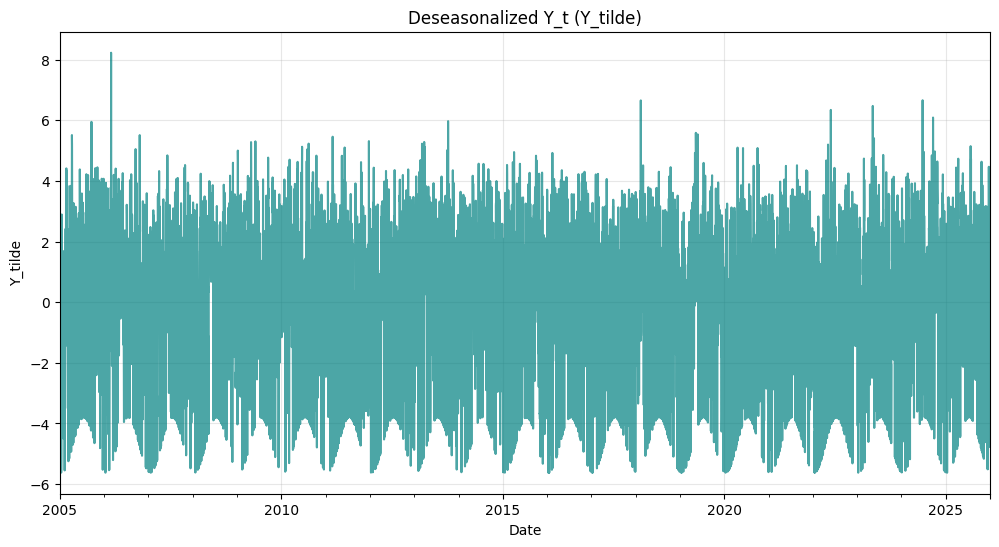

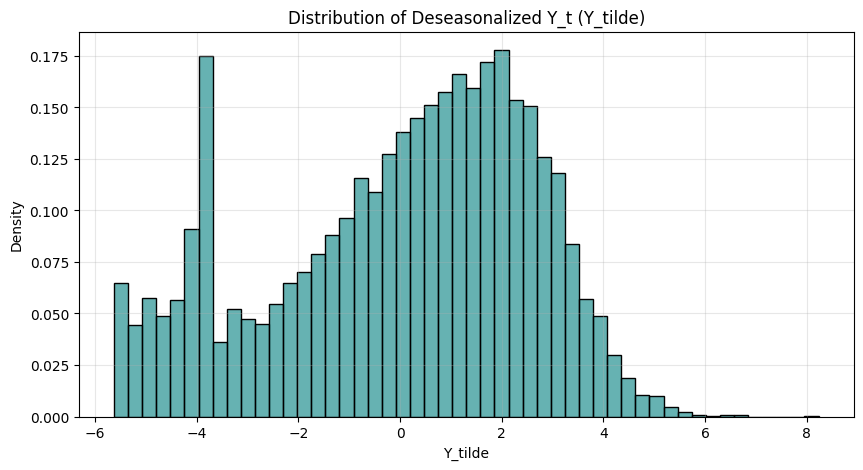

In [9]:
#Plot the Y_tilde series to visually inspect the deseasonalized data
plt.figure(figsize=(12, 6))
Y_tilde.plot(color='teal', alpha=0.7)
plt.title("Deseasonalized Y_t (Y_tilde)", fontsize=12)
plt.xlabel("Date")
plt.ylabel("Y_tilde")
plt.grid(alpha=0.3)
plt.show()

#Plot the distribution of the Y_tilde
plt.figure(figsize=(10, 5))
sns.histplot(Y_tilde, bins=50, color='teal', alpha=0.6, stat='density')
plt.title("Distribution of Deseasonalized Y_t (Y_tilde)", fontsize=12)
plt.xlabel("Y_tilde")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()



# Modelling

BIC grid (top 10):
 p  q          BIC          AIC
 2  1 34888.559324 34853.833964
 2  2 34897.037530 34855.367099
 3  1 34897.060739 34855.390308
 1  3 34902.913353 34861.242922
 1  2 34903.909439 34869.184080
 2  3 34905.466692 34856.851188
 3  2 34906.204999 34857.589495
 1  1 34908.874204 34881.093917
 2  0 34911.167262 34883.386974
 3  0 34911.817464 34877.092105

Selected order: ARMA(2, 1)


c:\Users\LucasMonero\Documents\data projects\Master Thesis\Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\LucasMonero\Documents\data projects\Master Thesis\Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\LucasMonero\Documents\data projects\Master Thesis\Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



AR coefficients : [ 1.2977 -0.3397]
MA coefficients : [-0.8998]
ε_t mean        : 0.0008  (expected ≈ 0)
ε_t std         : 2.3457

Ljung-Box on ε_t (lags 7, 30, 365):
        lb_stat  lb_pvalue
7      1.616820   0.977988
30    26.802453   0.633624
365  367.420781   0.454594


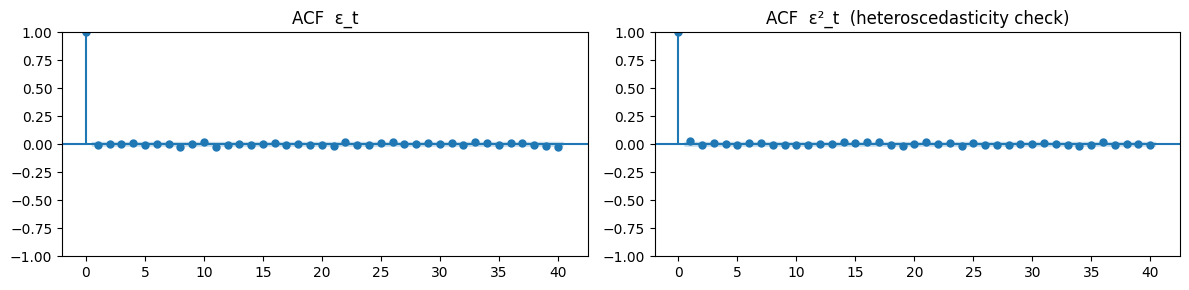

In [10]:
# Fit ARMA(p, q) on deseasonalized Ỹ_t ────────────────────────────
#
# Removes remaining autocorrelation in the conditional mean.
# Order selected by BIC over a grid of 36 combinations.
#
# Ỹ_t = Σ φ_k Ỹ_{t-k} + Σ θ_k ε_{t-k} + ε_t

import itertools
import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

def select_arma_order(
    Y_tilde: pd.Series,
    p_max: int = 3,
    q_max: int = 3,
) -> tuple[int, int, pd.DataFrame]:
    """
    Grid-search ARMA(p,q) orders minimising BIC.

    Returns
    -------
    best_p   : int          — selected AR order
    best_q   : int          — selected MA order
    bic_grid : pd.DataFrame — full BIC surface for inspection
    """
    results = []
    for p, q in itertools.product(range(1, p_max + 1), range(0, q_max + 1)):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                res = ARIMA(Y_tilde, order=(p, 0, q)).fit()
            results.append({"p": p, "q": q, "BIC": res.bic, "AIC": res.aic})
        except Exception:
            continue

    bic_grid = pd.DataFrame(results).sort_values("BIC").reset_index(drop=True)
    best_p   = int(bic_grid.loc[0, "p"])
    best_q   = int(bic_grid.loc[0, "q"])
    return best_p, best_q, bic_grid


def fit_arma(
    Y_tilde: pd.Series,
    p: int,
    q: int,
) -> tuple:
    """
    Fit ARMA(p, q) on Ỹ_t and return the fitted model and residuals ε_t.

    Returns
    -------
    arma_result : fitted ARIMA object
    epsilon     : pd.Series — ARMA residuals ε_t
    """
    arma_result = ARIMA(Y_tilde, order=(p, 0, q)).fit()
    epsilon     = pd.Series(arma_result.resid, index=Y_tilde.index, name="epsilon")
    return arma_result, epsilon


# ── Usage ─────────────────────────────────────────────────────────────────────

best_p, best_q, bic_grid = select_arma_order(Y_tilde)

print("BIC grid (top 10):")
print(bic_grid.head(10).to_string(index=False))
print(f"\nSelected order: ARMA({best_p}, {best_q})")

arma_result, epsilon = fit_arma(Y_tilde, best_p, best_q)

print(f"\nAR coefficients : {arma_result.arparams.round(4)}")
print(f"MA coefficients : {arma_result.maparams.round(4)}")
print(f"ε_t mean        : {epsilon.mean():.4f}  (expected ≈ 0)")
print(f"ε_t std         : {epsilon.std():.4f}")

# ── Diagnostics ───────────────────────────────────────────────────────────────

# Ljung-Box on ε_t — should not be significant at lags 7 and 30
lb = acorr_ljungbox(epsilon.dropna(), lags=[7, 30, 365], return_df=True)
print(f"\nLjung-Box on ε_t (lags 7, 30, 365):")
print(lb[["lb_stat", "lb_pvalue"]].to_string())

# ACF of ε² — significant values indicate remaining heteroscedasticity → GARCH needed
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
plot_acf(epsilon.dropna(),    ax=axes[0], lags=40, title="ACF  ε_t")
plot_acf(epsilon.dropna()**2, ax=axes[1], lags=40, title="ACF  ε²_t  (heteroscedasticity check)")
plt.tight_layout()
plt.show()

In [11]:
from statsmodels.stats.diagnostic import het_arch

lm_stat, lm_p, f_stat, f_p = het_arch(epsilon.dropna(), nlags=10)
print(f"ARCH-LM stat: {lm_stat:.4f},  p-value: {lm_p:.4f}")

ARCH-LM stat: 10.8664,  p-value: 0.3680


## Montly GMM

Month   μ_cloudy  σ_cloudy  w_cloudy   μ_sunny   σ_sunny   w_sunny
---------------------------------------------------------------
Jan       -2.148     1.964     0.357     1.220     1.385     0.643
Feb       -2.735     1.739     0.367     1.336     1.546     0.633
Mar       -3.048     1.702     0.320     1.178     1.528     0.680
Apr       -2.398     1.712     0.340     1.338     1.453     0.660
May       -1.740     1.987     0.311     1.268     1.425     0.689
Jun       -2.262     1.548     0.334     1.172     1.337     0.666
Jul       -2.425     1.293     0.408     1.371     1.392     0.592
Aug       -2.460     1.374     0.416     1.393     1.436     0.584
Sep       -2.431     1.415     0.390     1.511     1.391     0.610
Oct       -2.371     1.775     0.321     1.388     1.499     0.679
Nov       -2.180     2.048     0.347     1.444     1.341     0.653
Dec       -2.458     1.807     0.340     1.178     1.297     0.660

KS test on PIT grades:  stat = 0.0087,  p-value = 0.5975
Distrib

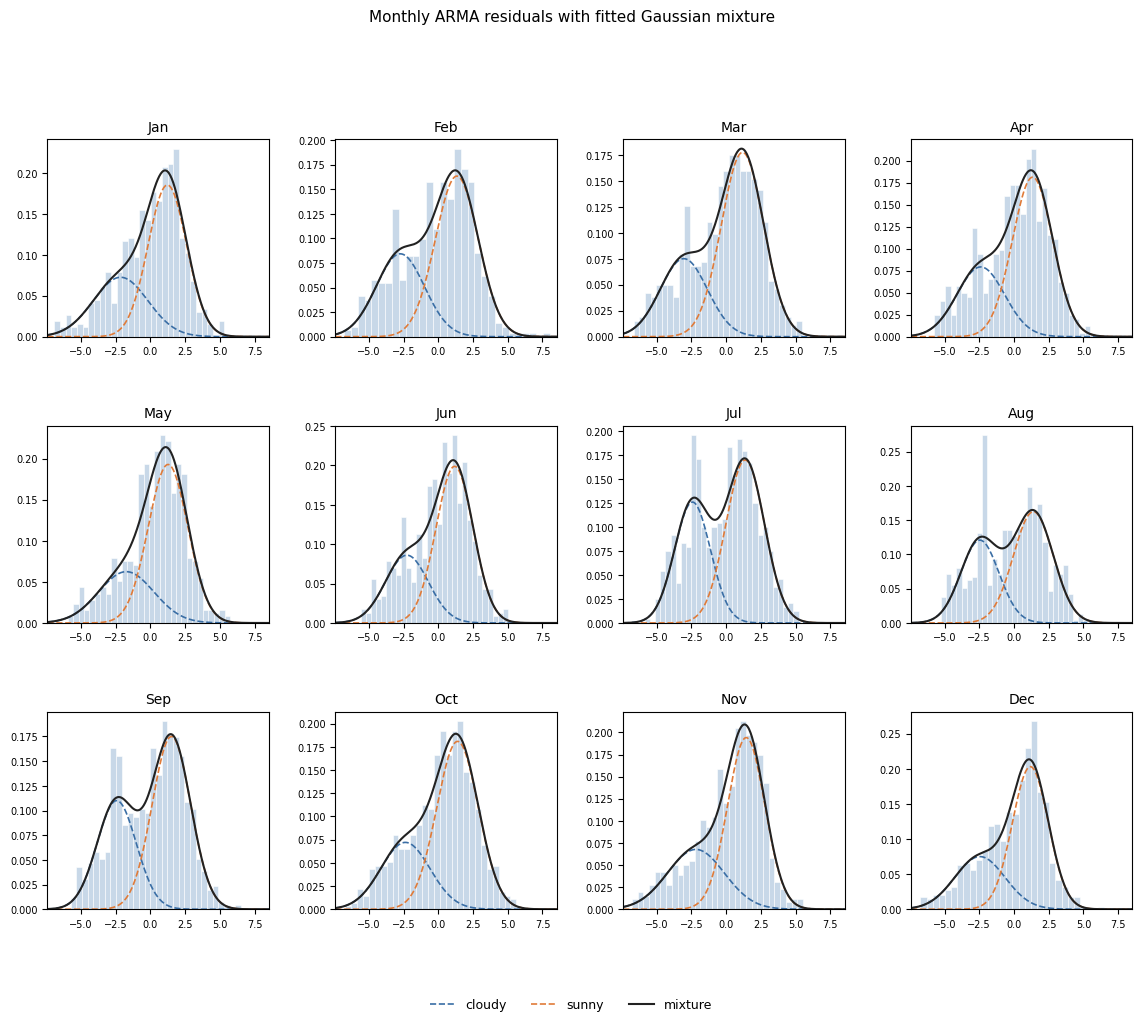

In [12]:

# ε_t reflects the mixing of sunny and cloudy regimes whose statistical
# character changes month by month. A two-component Gaussian mixture
# captures this bimodality, estimated separately for each calendar month.
#
# ε_t ~ (μ₁ + σ₁·Z₁)·B_t + (μ₀ + σ₀·Z₀)·(1 - B_t)
# B_t ~ Bernoulli(p_m),  Z₀, Z₁ ~ N(0,1)

from sklearn.mixture import GaussianMixture
from scipy.stats import kstest, norm
import matplotlib.gridspec as gridspec

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]


def fit_monthly_mixture(
    epsilon: pd.Series,
    months: pd.Series,
) -> dict:
    """
    Fit a 2-component Gaussian mixture per calendar month via EM.

    Returns
    -------
    mixture_params : dict  — keyed by month (1..12), each entry contains
                             means, stds, weights of the two components
    """
    mixture_params = {}
    for m in range(1, 13):
        eps_m = epsilon[months == m].values.reshape(-1, 1)
        gm    = GaussianMixture(n_components=2, random_state=0).fit(eps_m)

        # Sort components: component 0 = cloudy (lower mean), 1 = sunny (higher mean)
        order = np.argsort(gm.means_.flatten())
        mixture_params[m] = {
            "means"  : gm.means_.flatten()[order],
            "stds"   : np.sqrt(gm.covariances_.flatten())[order],
            "weights": gm.weights_[order],
        }
    return mixture_params


def pit_grades(
    epsilon: pd.Series,
    months: pd.Series,
    mixture_params: dict,
) -> pd.Series:
    """
    Compute Probability Integral Transform grades for each ε_t.
    Under a correctly specified model, PIT grades ~ Uniform(0, 1).
    """
    pit = np.empty(len(epsilon))
    for m in range(1, 13):
        idx  = (months == m).values
        e_m  = epsilon.values[idx]
        mp   = mixture_params[m]
        # Mixture CDF: weighted sum of two normal CDFs
        pit[idx] = (
            mp["weights"][0] * norm.cdf(e_m, mp["means"][0], mp["stds"][0]) +
            mp["weights"][1] * norm.cdf(e_m, mp["means"][1], mp["stds"][1])
        )
    return pd.Series(pit, index=epsilon.index, name="PIT")


# ── Usage ─────────────────────────────────────────────────────────────────────

months = pd.Series(epsilon.index.month, index=epsilon.index)
mixture_params = fit_monthly_mixture(epsilon, months)
pit = pit_grades(epsilon, months, mixture_params)

# ── Summary table ─────────────────────────────────────────────────────────────

print(f"{'Month':<6} {'μ_cloudy':>9} {'σ_cloudy':>9} {'w_cloudy':>9} "
      f"{'μ_sunny':>9} {'σ_sunny':>9} {'w_sunny':>9}")
print("-" * 63)
for m in range(1, 13):
    mp = mixture_params[m]
    print(f"{MONTH_NAMES[m-1]:<6} "
          f"{mp['means'][0]:>9.3f} {mp['stds'][0]:>9.3f} {mp['weights'][0]:>9.3f} "
          f"{mp['means'][1]:>9.3f} {mp['stds'][1]:>9.3f} {mp['weights'][1]:>9.3f}")

# ── Diagnostics ───────────────────────────────────────────────────────────────

# KS test on PIT grades — null: Uniform(0,1); reject → distributional misfit
ks_stat, ks_p = kstest(pit, "uniform")
print(f"\nKS test on PIT grades:  stat = {ks_stat:.4f},  p-value = {ks_p:.4f}")
print("Distributional fit adequate" if ks_p > 0.05 else "WARNING: distributional misfit detected")

# ── Visual: monthly histograms + fitted mixture densities ─────────────────────

x_grid = np.linspace(epsilon.min() - 0.5, epsilon.max() + 0.5, 300)
fig    = plt.figure(figsize=(14, 10))
gs     = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.3)

for m in range(1, 13):
    ax  = fig.add_subplot(gs[(m-1)//4, (m-1)%4])
    eps_m = epsilon[months == m].values
    mp    = mixture_params[m]

    ax.hist(eps_m, bins=30, density=True, color="#c8d8e8", edgecolor="white", linewidth=0.4)

    # Individual components
    pdf_cloudy = mp["weights"][0] * norm.pdf(x_grid, mp["means"][0], mp["stds"][0])
    pdf_sunny  = mp["weights"][1] * norm.pdf(x_grid, mp["means"][1], mp["stds"][1])
    pdf_mix    = pdf_cloudy + pdf_sunny

    ax.plot(x_grid, pdf_cloudy, color="#3a6ea5", linewidth=1.2, linestyle="--", label="cloudy")
    ax.plot(x_grid, pdf_sunny,  color="#e07b39", linewidth=1.2, linestyle="--", label="sunny")
    ax.plot(x_grid, pdf_mix,    color="#222222", linewidth=1.5, label="mixture")

    ax.set_title(MONTH_NAMES[m-1], fontsize=10)
    ax.set_xlim(x_grid[0], x_grid[-1])
    ax.tick_params(labelsize=7)

handles, labels = fig.axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=9, frameon=False)
plt.suptitle("Monthly ARMA residuals with fitted Gaussian mixture", fontsize=11, y=1.01)
plt.show()

Residuals mean : -0.1012  (expected ≈ 0)
Residuals std  : 0.2326
Residuals range: [-0.8415, 0.7515]


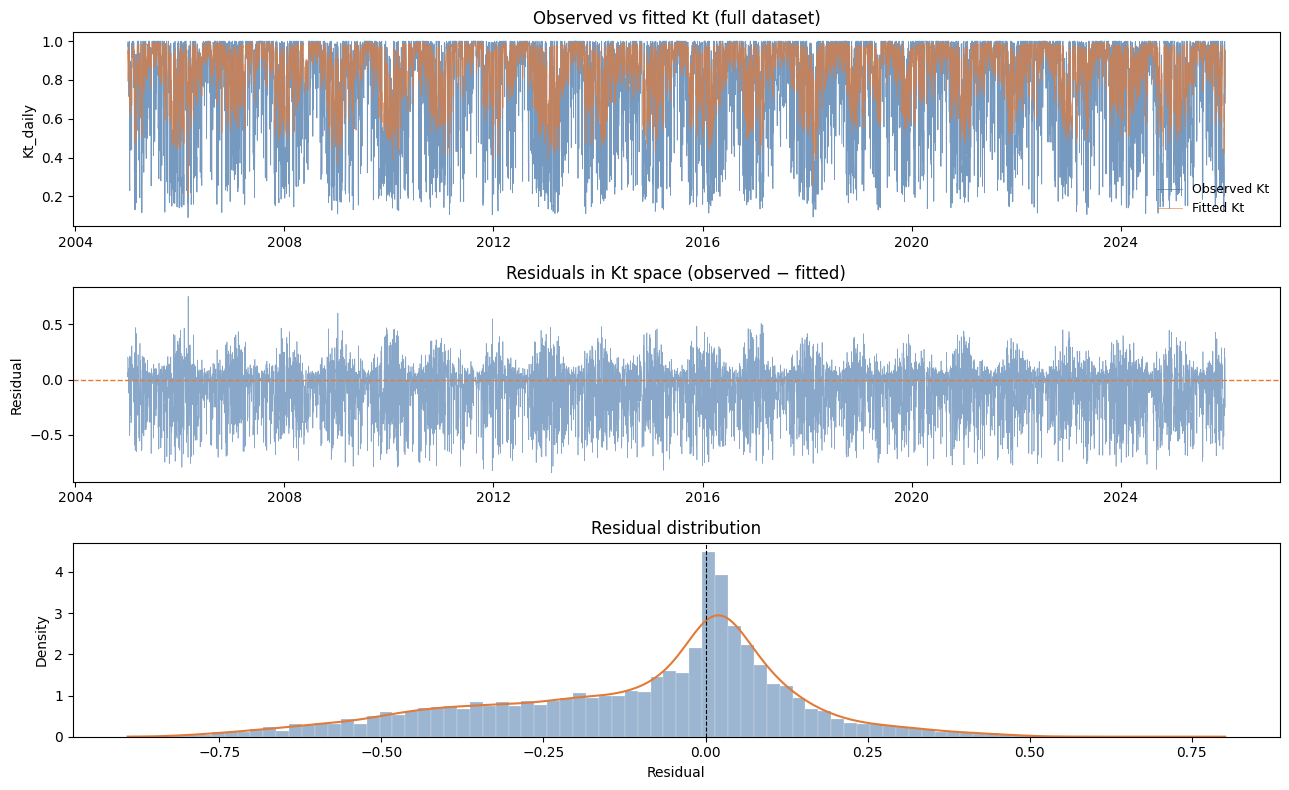

In [13]:
# ── Residuals: fitted Kt vs observed Kt (full dataset) ────────────────────────
#
# Reconstruct fitted Kt from the full pipeline on the full dataset:
#   ARMA fitted values → add seasonal mean → invert logit → Kt_fitted
# Residuals = Kt_observed - Kt_fitted

alpha = params["alpha"]
beta  = params["beta"]

# ARMA fitted values on full dataset (Ỹ_t fitted)
Ytilde_fitted = pd.Series(arma_result.fittedvalues, index=kt.index, name="Ytilde_fitted")

# Add seasonal mean back → Y_t fitted
Yt_fitted     = Ytilde_fitted + Y_bar

# Invert logit → Kt fitted
Xp_fitted     = 1.0 / (1.0 + np.exp(-Yt_fitted.values))
Kt_fitted     = pd.Series(
    1.0 - (alpha + beta * Xp_fitted),
    index=kt.index,
    name="Kt_fitted"
)

# Residuals in Kt space
Kt_residuals  = pd.Series(
    kt.values - Kt_fitted.values,
    index=kt.index,
    name="Kt_residuals"
)

# ── Summary ───────────────────────────────────────────────────────────────────

print(f"Residuals mean : {Kt_residuals.mean():.4f}  (expected ≈ 0)")
print(f"Residuals std  : {Kt_residuals.std():.4f}")
print(f"Residuals range: [{Kt_residuals.min():.4f}, {Kt_residuals.max():.4f}]")

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=False)

# Top: observed vs fitted Kt over time
axes[0].plot(kt.index, kt.values,        color="#3a6ea5", linewidth=0.6,
             alpha=0.7, label="Observed Kt")
axes[0].plot(kt.index, Kt_fitted.values, color="#e07b39", linewidth=0.6,
             alpha=0.7, label="Fitted Kt")
axes[0].set_ylabel("Kt_daily")
axes[0].set_title("Observed vs fitted Kt (full dataset)")
axes[0].legend(frameon=False, fontsize=9)

# Middle: residuals over time
axes[1].plot(kt.index, Kt_residuals.values, color="#3a6ea5", linewidth=0.5, alpha=0.6)
axes[1].axhline(0, color="#e07b39", linewidth=1.0, linestyle="--")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals in Kt space (observed − fitted)")

# Bottom: residual distribution
axes[2].hist(Kt_residuals.values, bins=80, density=True,
             color="#3a6ea5", alpha=0.5, edgecolor="white", linewidth=0.3)
kde_res = gaussian_kde(Kt_residuals.values)
x_res   = np.linspace(Kt_residuals.min() - 0.05, Kt_residuals.max() + 0.05, 300)
axes[2].plot(x_res, kde_res(x_res), color="#e07b39", linewidth=1.5)
axes[2].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Density")
axes[2].set_title("Residual distribution")

plt.tight_layout()
plt.show()

The model is overestimating the Kt and aparently not indentifyng a seasonal movement, since the re is higher residuals on the winter

# Validation

In [14]:

# Pipeline is refit exclusively on the training set.
# The held-out test set (last 2 years) is used only for evaluation.
#
# Metrics:
#   - Point forecasts : RMSE, MAE, MAPE on Kt_daily
#   - VaR coverage    : Bernoulli test at 10%, 20%, 80%, 90% quantiles

from statsmodels.tsa.arima.model import ARIMA
from sklearn.mixture import GaussianMixture
from scipy.stats import kstest, norm, binom
import warnings

# ── Train / test split ────────────────────────────────────────────────────────

cutoff     = df_daily_2["date"].max() - pd.DateOffset(years=5)
df_train   = df_daily_2[df_daily_2["date"] <= cutoff].copy()
df_test    = df_daily_2[df_daily_2["date"] >  cutoff].copy()

print(f"Train: {df_train['date'].min().date()} → {df_train['date'].max().date()}  ({len(df_train)} days)")
print(f"Test : {df_test['date'].min().date()}  → {df_test['date'].max().date()}   ({len(df_test)} days)")

# ── Refit pipeline on training set only ───────────────────────────────────────

# Step 3 — transformation (fit params on train only)
kt_train     = df_train.set_index("date")["Kt_daily"].dropna()
Xt_train     = 1.0 - kt_train
alpha_tr     = float(Xt_train.min()) - EPS
beta_tr      = float(Xt_train.max() - Xt_train.min()) + 2 * EPS
Xp_train     = (Xt_train - alpha_tr) / beta_tr
Yt_train     = pd.Series(np.log(Xp_train / (1 - Xp_train)), index=kt_train.index, name="Y_t")

# Step 4 — seasonal mean (fit on train only)
t_train      = np.arange(len(Yt_train))
X_seas_train = np.column_stack([
    np.ones(len(t_train)),
    np.cos(2 * np.pi * t_train / 365),
    np.sin(2 * np.pi * t_train / 365),
])
a_train      = np.linalg.lstsq(X_seas_train, Yt_train.values, rcond=None)[0]
Ybar_train   = X_seas_train @ a_train
Ytilde_train = Yt_train.values - Ybar_train

# Step 5 — ARMA (fit on train only)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    arma_tr  = ARIMA(Ytilde_train, order=(best_p, 0, best_q)).fit()
eps_train    = arma_tr.resid

# Step 7 — monthly GM (fit on train only)
months_train     = kt_train.index.month
months_train_s   = pd.Series(months_train, index=kt_train.index)
gm_params_train  = fit_monthly_mixture(
    pd.Series(eps_train, index=kt_train.index), months_train_s
)

# ── Generate day-ahead forecasts on test set ──────────────────────────────────

n_test       = len(df_test)
kt_test      = df_test.set_index("date")["Kt_daily"].dropna()

# Compute test-set t index continuing from train
t_test       = np.arange(len(Yt_train), len(Yt_train) + n_test)
X_seas_test  = np.column_stack([
    np.ones(n_test),
    np.cos(2 * np.pi * t_test / 365),
    np.sin(2 * np.pi * t_test / 365),
])
Ybar_test    = X_seas_test @ a_train   # deterministic component on test dates

# One-step-ahead conditional mean forecast from ARMA
arma_forecast = arma_tr.forecast(steps=n_test)  # Ỹ_t forecast
Yt_forecast   = arma_forecast + Ybar_test        # add seasonal mean back

# Invert Y_t forecast → Kt forecast
Xp_fc    = 1.0 / (1.0 + np.exp(-Yt_forecast))   # logistic inverse
Xt_fc    = alpha_tr + beta_tr * Xp_fc
Kt_fc    = pd.Series(1.0 - Xt_fc, index=kt_test.index, name="Kt_forecast")

# ── Point forecast metrics ────────────────────────────────────────────────────

kt_obs   = kt_test.loc[Kt_fc.index]
errors   = kt_obs - Kt_fc

rmse     = np.sqrt((errors ** 2).mean())
mae      = errors.abs().mean()
mape     = (errors.abs() / kt_obs.abs()).mean() * 100

print(f"\nPoint forecast metrics (Kt_daily, test set):")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  MAPE : {mape:.2f}%")

# ── VaR coverage (Bernoulli test) ─────────────────────────────────────────────
#
# For each quantile level q, count how many observations fall below the
# forecast quantile. Under correct specification: violation rate = q.
# Bernoulli test H0: true violation rate = q.

def forecast_quantile(
    q: float,
    Yt_fc: np.ndarray,
    gm_params: dict,
    months_test: np.ndarray,
    alpha: float,
    beta: float,
) -> np.ndarray:
    """
    Compute the q-th quantile of Kt at each test date by inverting the
    mixture CDF of Y_t via bisection.
    """
    quantiles = np.empty(len(Yt_fc))
    for i, (y_mu, m) in enumerate(zip(Yt_fc, months_test)):
        mp  = gm_params[m]
        # Mixture CDF evaluated at candidate y values (shifted by ARMA forecast mean)
        def mixture_cdf(y):
            return (mp["weights"][0] * norm.cdf(y - y_mu, mp["means"][0], mp["stds"][0]) +
                    mp["weights"][1] * norm.cdf(y - y_mu, mp["means"][1], mp["stds"][1]))

        # Bisection over Y_t space
        lo, hi = -20.0, 20.0
        for _ in range(60):
            mid = (lo + hi) / 2
            if mixture_cdf(mid) < (1 - q):
                lo = mid
            else:
                hi = mid
        y_q = (lo + hi) / 2

        # Invert Y_t quantile → Kt quantile
        Xp_q        = 1.0 / (1.0 + np.exp(-y_q))
        quantiles[i] = 1.0 - (alpha + beta * Xp_q)

    return quantiles


months_test_arr = kt_test.index.month
print(f"\nVaR coverage rates (test set, n={n_test} days):")
print(f"{'Quantile':>10} {'Expected':>10} {'Observed':>10} {'Violations':>12} {'Binom p':>10}")
print("-" * 55)

for q in [0.10, 0.20, 0.80, 0.90]:
    q_vals     = forecast_quantile(q, Yt_forecast, gm_params_train,
                                   months_test_arr, alpha_tr, beta_tr)
    violations = int((kt_obs.values < q_vals).sum())
    obs_rate   = violations / n_test
    # Bernoulli test: H0 — true rate = q
    binom_p    = binom.cdf(violations, n_test, q) if obs_rate <= q \
                 else 1 - binom.cdf(violations - 1, n_test, q)
    print(f"{q:>10.0%} {q:>10.0%} {obs_rate:>10.2%} {violations:>12} {binom_p:>10.4f}")

Train: 2005-01-01 → 2020-12-31  (5844 days)
Test : 2021-01-01  → 2025-12-31   (1826 days)

Point forecast metrics (Kt_daily, test set):
  RMSE : 0.2824
  MAE  : 0.2053
  MAPE : 53.47%

VaR coverage rates (test set, n=1826 days):
  Quantile   Expected   Observed   Violations    Binom p
-------------------------------------------------------
       10%        10%     11.99%          219     0.0031
       20%        20%     23.33%          426     0.0003
       80%        80%     76.29%         1393     0.0001
       90%        90%     82.48%         1506     0.0000


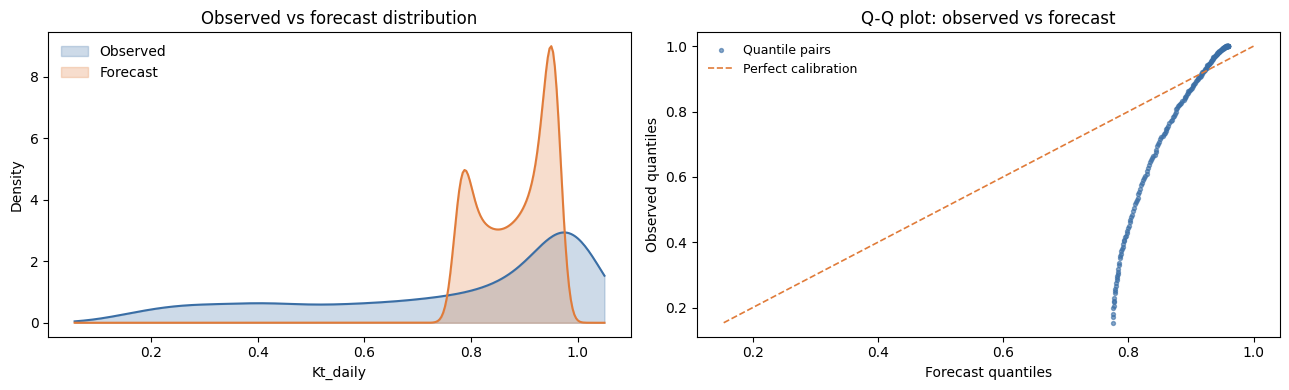

In [15]:
# ── Visual: observed vs forecast Kt distribution (test set) ──────────────────


fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: full distribution overlay ──────────────────────────────────────────

kt_obs_vals = kt_obs.values
kt_fc_vals  = Kt_fc.values

x_grid = np.linspace(
    min(kt_obs_vals.min(), kt_fc_vals.min()) - 0.05,
    max(kt_obs_vals.max(), kt_fc_vals.max()) + 0.05,
    300
)

kde_obs = gaussian_kde(kt_obs_vals)
kde_fc  = gaussian_kde(kt_fc_vals)

axes[0].fill_between(x_grid, kde_obs(x_grid), alpha=0.25, color="#3a6ea5", label="Observed")
axes[0].fill_between(x_grid, kde_fc(x_grid),  alpha=0.25, color="#e07b39", label="Forecast")
axes[0].plot(x_grid, kde_obs(x_grid), color="#3a6ea5", linewidth=1.5)
axes[0].plot(x_grid, kde_fc(x_grid),  color="#e07b39", linewidth=1.5)
axes[0].set_xlabel("Kt_daily")
axes[0].set_ylabel("Density")
axes[0].set_title("Observed vs forecast distribution")
axes[0].legend(frameon=False)

# ── Right: Q-Q plot (observed quantiles vs forecast quantiles) ────────────────

quantile_levels = np.linspace(0.01, 0.99, 200)
q_obs = np.quantile(kt_obs_vals, quantile_levels)
q_fc  = np.quantile(kt_fc_vals,  quantile_levels)

axes[1].scatter(q_fc, q_obs, s=8, color="#3a6ea5", alpha=0.6, label="Quantile pairs")
axes[1].plot(
    [min(q_fc.min(), q_obs.min()), max(q_fc.max(), q_obs.max())],
    [min(q_fc.min(), q_obs.min()), max(q_fc.max(), q_obs.max())],
    color="#e07b39", linewidth=1.2, linestyle="--", label="Perfect calibration"
)
axes[1].set_xlabel("Forecast quantiles")
axes[1].set_ylabel("Observed quantiles")
axes[1].set_title("Q-Q plot: observed vs forecast")
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

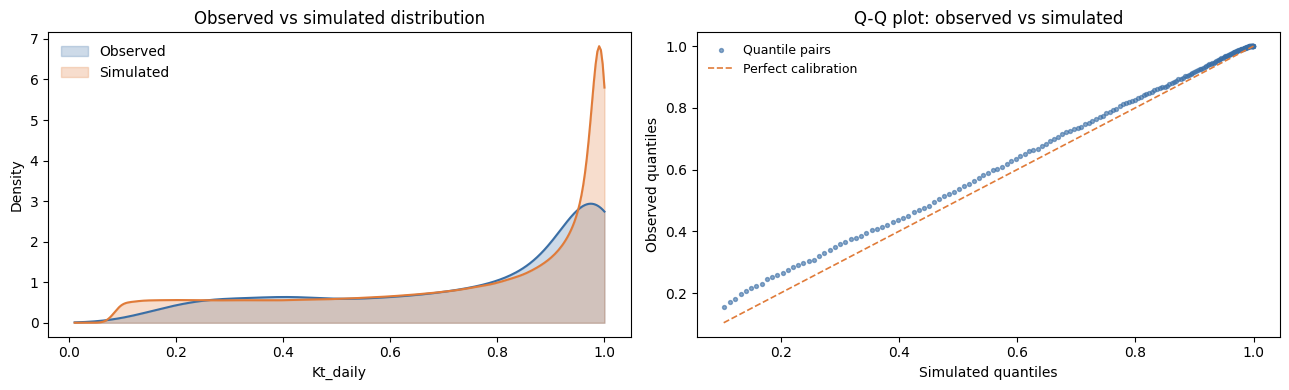

In [16]:
# ── simulating Kt distribution from the fitted model ────────────────
#
# The forecast distribution must be generated by propagating noise through
# the full pipeline: ARMA mean + mixture innovation → Y_t → Kt
# NOT by inverting the deterministic ARMA point forecast alone.

N_SIMS = 2000   # number of Monte Carlo trajectories

np.random.seed(42)

def simulate_kt_trajectories(
    n_steps:       int,
    arma_result,
    gm_params:     dict,
    a_seasonal:    np.ndarray,
    t_start:       int,
    alpha:         float,
    beta:          float,
    n_sims:        int = N_SIMS,
) -> np.ndarray:
    """
    Simulate n_sims trajectories of Kt over n_steps days.

    For each trajectory:
      1. Draw mixture innovations u_t from the monthly GM
      2. Propagate through ARMA recursion → Ỹ_t
      3. Add seasonal mean → Y_t
      4. Invert logit → Kt

    Returns
    -------
    kt_sims : np.ndarray, shape (n_sims, n_steps)
    """
    phi   = arma_result.arparams          # AR coefficients
    theta = arma_result.maparams          # MA coefficients
    p, q  = len(phi), len(theta)

    # Seasonal mean on test dates
    t_test_idx   = np.arange(t_start, t_start + n_steps)
    X_seas       = np.column_stack([
        np.ones(n_steps),
        np.cos(2 * np.pi * t_test_idx / 365),
        np.sin(2 * np.pi * t_test_idx / 365),
    ])
    Y_bar_test   = X_seas @ a_seasonal    # shape (n_steps,)

    # Calendar months for test dates
    test_months  = (kt_test.index.month).values   # shape (n_steps,)

    kt_sims      = np.empty((n_sims, n_steps))

    # Initialise AR and MA buffers from end of training residuals
    ar_init = np.array(arma_result.fittedvalues[-p:]) if p > 0 else np.array([])
    ma_init = np.array(arma_result.resid[-q:])        if q > 0 else np.array([])

    for s in range(n_sims):
        ytilde_buf = list(ar_init)   # rolling buffer of Ỹ_{t-k}
        eps_buf    = list(ma_init)   # rolling buffer of ε_{t-k}

        for i in range(n_steps):
            m  = test_months[i]
            mp = gm_params[m]

            # Draw innovation from monthly mixture
            component = np.random.choice([0, 1], p=mp["weights"])
            u_t       = np.random.normal(mp["means"][component],
                                         mp["stds"][component])

            # ARMA recursion: Ỹ_t = Σ φ_k Ỹ_{t-k} + Σ θ_k ε_{t-k} + u_t
            ar_term   = sum(phi[k]   * ytilde_buf[-(k+1)] for k in range(min(p, len(ytilde_buf))))
            ma_term   = sum(theta[k] * eps_buf[-(k+1)]    for k in range(min(q, len(eps_buf))))
            ytilde_t  = ar_term + ma_term + u_t

            ytilde_buf.append(ytilde_t)
            eps_buf.append(u_t)

            # Add seasonal mean → Y_t
            Y_t       = ytilde_t + Y_bar_test[i]

            # Invert logit → Kt
            Xp_t      = 1.0 / (1.0 + np.exp(-Y_t))
            Xt_t      = alpha + beta * Xp_t
            kt_sims[s, i] = 1.0 - Xt_t

    return kt_sims


kt_sims = simulate_kt_trajectories(
    n_steps     = n_test,
    arma_result = arma_tr,
    gm_params   = gm_params_train,
    a_seasonal  = a_train,
    t_start     = len(Yt_train),
    alpha       = alpha_tr,
    beta        = beta_tr,
)

# Flatten all simulated values — this is the simulated marginal distribution
kt_sim_flat = kt_sims.flatten()
kt_sim_flat = kt_sim_flat[(kt_sim_flat > 0) & (kt_sim_flat < 1)]  # discard boundary artifacts

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_grid  = np.linspace(0.01, 1.0, 300)
kde_obs = gaussian_kde(kt_obs_vals)
kde_sim = gaussian_kde(kt_sim_flat)

axes[0].fill_between(x_grid, kde_obs(x_grid), alpha=0.25, color="#3a6ea5", label="Observed")
axes[0].fill_between(x_grid, kde_sim(x_grid), alpha=0.25, color="#e07b39", label="Simulated")
axes[0].plot(x_grid, kde_obs(x_grid), color="#3a6ea5", linewidth=1.5)
axes[0].plot(x_grid, kde_sim(x_grid), color="#e07b39", linewidth=1.5)
axes[0].set_xlabel("Kt_daily")
axes[0].set_ylabel("Density")
axes[0].set_title("Observed vs simulated distribution")
axes[0].legend(frameon=False)

quantile_levels = np.linspace(0.01, 0.99, 200)
q_obs = np.quantile(kt_obs_vals,  quantile_levels)
q_sim = np.quantile(kt_sim_flat,  quantile_levels)

axes[1].scatter(q_sim, q_obs, s=8, color="#3a6ea5", alpha=0.6, label="Quantile pairs")
axes[1].plot(
    [min(q_sim.min(), q_obs.min()), max(q_sim.max(), q_obs.max())],
    [min(q_sim.min(), q_obs.min()), max(q_sim.max(), q_obs.max())],
    color="#e07b39", linewidth=1.2, linestyle="--", label="Perfect calibration"
)
axes[1].set_xlabel("Simulated quantiles")
axes[1].set_ylabel("Observed quantiles")
axes[1].set_title("Q-Q plot: observed vs simulated")
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

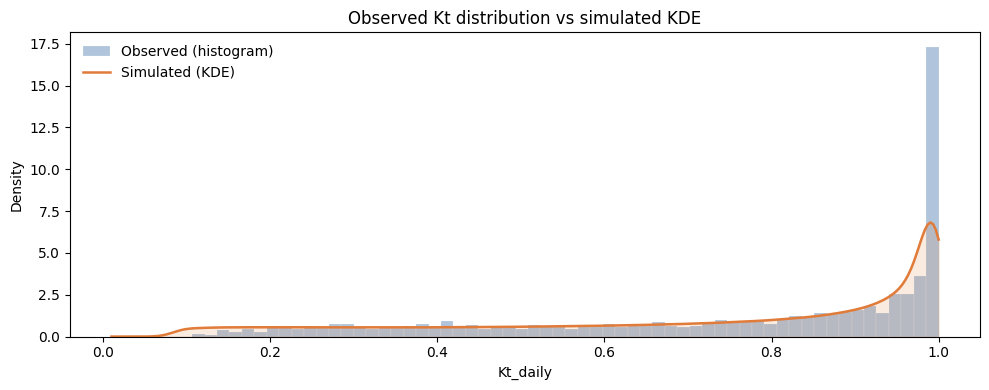

In [17]:
# ── Observed histogram + simulated KDE overlay ───────────────────────────────

fig, ax = plt.subplots(figsize=(10, 4))

# Observed — histogram
ax.hist(
    kt_obs_vals,
    bins=60,
    density=True,
    color="#3a6ea5",
    alpha=0.4,
    edgecolor="white",
    linewidth=0.3,
    label="Observed (histogram)"
)

# Simulated — KDE only
ax.plot(x_grid, kde_sim(x_grid), color="#e07b39", linewidth=1.8, label="Simulated (KDE)")
ax.fill_between(x_grid, kde_sim(x_grid), alpha=0.15, color="#e07b39")

ax.set_xlabel("Kt_daily")
ax.set_ylabel("Density")
ax.set_title("Observed Kt distribution vs simulated KDE")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# Saving the model

In [18]:
# ── Save fitted models ────────────────────────────────────────────────────────
import os, json, pickle

MODELS_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "Models")
os.makedirs(MODELS_DIR, exist_ok=True)

# 1. ARMA model (statsmodels native format)
arma_result.save(os.path.join(MODELS_DIR, "ghi_arma_result.pkl"))

# 2. Monthly GMM parameters (dict keyed 1..12)
with open(os.path.join(MODELS_DIR, "ghi_mixture_params.pkl"), "wb") as f:
    pickle.dump(mixture_params, f)

# 3. Seasonal mean coefficients (Fourier terms vector a)
with open(os.path.join(MODELS_DIR, "ghi_seasonal_coeffs.pkl"), "wb") as f:
    pickle.dump(a, f)

# 4. Scalar parameters as JSON (human-readable)
meta = {
    "arma_order": {"p": int(best_p), "q": int(best_q)},
    "logit_transform": {"alpha": float(params["alpha"]), "beta": float(params["beta"])},
}
with open(os.path.join(MODELS_DIR, "model_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print("Saved to:", MODELS_DIR)
print("  ghi_arma_result.pkl    — ARMA fitted model")
print("  ghi_mixture_params.pkl — monthly GMM parameters (months 1–12)")
print("  ghi_seasonal_coeffs.pkl — Fourier seasonal mean coefficients (a)")
print("  model_meta.json    — ARMA order, alpha, beta")


Saved to: c:\Users\LucasMonero\Documents\data projects\Master Thesis\Project\Code\Modelling\..\Models
  ghi_arma_result.pkl    — ARMA fitted model
  ghi_mixture_params.pkl — monthly GMM parameters (months 1–12)
  ghi_seasonal_coeffs.pkl — Fourier seasonal mean coefficients (a)
  model_meta.json    — ARMA order, alpha, beta


# Constructing the final dataframe

In [19]:
# ── Final modelled dataframe ──────────────────────────────────────────────────
#
# Assembles every pipeline stage into a single aligned dataframe:
#   Original → logit transform → seasonal mean → ARMA fit → residuals

df_modelled = (
    pd.DataFrame(index=kt.index)
    # Original
    .assign(
        Kt          = kt,
        GHI_obs     = GHI_obs,
        GHI_cs      = Ct,
    )
    # Logit transform
    .assign(Yt      = Yt)
    # Seasonal decomposition
    .assign(
        Y_bar       = Y_bar,
        Y_tilde     = Y_tilde,
    )
    # ARMA conditional mean
    .assign(
        Ytilde_fitted = Ytilde_fitted,
        epsilon       = epsilon,          # ARMA residuals in Ỹ_t space
    )
    # Back-transformed to Kt space
    .assign(
        Kt_fitted   = Kt_fitted,
        Kt_residuals= Kt_residuals,       # residuals in original Kt scale
    )
)

print(df_modelled.shape)
print(df_modelled.describe().round(4))
df_modelled.head()


(7670, 10)
              Kt    GHI_obs     GHI_cs         Yt      Y_bar    Y_tilde  \
count  7670.0000  7670.0000  7670.0000  7670.0000  7670.0000  7670.0000   
mean      0.7513  4085.1976  5203.4829    -2.1027    -2.1027    -0.0000   
std       0.2641  2444.0031  2262.4914     2.6672     0.6467     2.5876   
min       0.0907   192.1820  1535.1197    -6.8138    -3.0176    -5.6247   
25%       0.5515  1944.9330  2936.7479    -3.9164    -2.7501    -1.7669   
50%       0.8598  3832.5555  5302.7245    -1.6967    -2.1010     0.4680   
75%       0.9832  6294.9200  7408.9890    -0.0270    -1.4599     2.0075   
max       1.0000  8898.3843  8898.3843     6.8138    -1.1890     8.2305   

       Ytilde_fitted    epsilon  Kt_fitted  Kt_residuals  
count      7670.0000  7670.0000  7670.0000     7670.0000  
mean         -0.0008     0.0008     0.8525       -0.1012  
std           1.0928     2.3457     0.1301        0.2326  
min          -2.7354    -6.9141     0.2024       -0.8415  
25%          -0.74

,Kt,GHI_obs,GHI_cs,Yt,Y_bar,Y_tilde,Ytilde_fitted,epsilon,Kt_fitted,Kt_residuals
date,,,,,,,,,,
2005-01-01,0.995880,2119.085016,2127.852121,-5.176096,-1.219759,-3.956337,-0.001983,-3.954354,0.793551,0.202328
2005-01-02,0.975048,1982.049556,2032.770931,-3.529785,-1.215844,-2.313940,-1.650079,-0.663861,0.951912,0.023137
2005-01-03,0.978315,1879.852110,1921.520051,-3.668011,-1.212193,-2.455818,-1.064787,-1.391031,0.916202,0.062113
2005-01-04,0.958614,2037.694044,2125.667418,-3.020467,-1.208805,-1.811662,-1.154873,-0.656788,0.922639,0.035975
2005-01-05,0.935303,1963.360307,2099.169946,-2.555048,-1.205683,-1.349365,-0.927915,-0.421450,0.904513,0.030790


# Saving the final dataframe

In [20]:
# ── Save modelled dataframe ───────────────────────────────────────────────────

output_path = Path("../../Data/Modelled/df_solar_modelled.parquet")

df_modelled.to_parquet(output_path, index=True)

print(f"[SAVED] {output_path.resolve()}")
print(f"  Shape : {df_modelled.shape}")


[SAVED] C:\Users\LucasMonero\Documents\data projects\Master Thesis\Project\Data\Modelled\df_solar_modelled.parquet
  Shape : (7670, 10)
